# 17 · Unsupervised Analysis — Patient Phenotyping & Association-Rule Mining

The other notebooks in this project frame HIV viral-load suppression as a **supervised**
problem (predict `undetectable`). This notebook steps back and asks two *unsupervised*
questions on the same WIHS cohort:

1. **Clustering** — do patients fall into natural *phenotype groups* based on their immune
   markers, treatment intensity, and visit history? *(one row per patient)*
2. **Association-rule mining** — which combinations of clinical / genetic / behavioural
   factors *co-occur* more than chance, and which patterns are associated with suppression?
   *(one row per visit)*

The target `undetectable` is **held out** of both models and used only afterwards to
*interpret* the groups and rules.

> **Design note.** All figures use a colour-blind-safe, contrast-validated palette
> (blue = below average / cool, red = above average / warm; one hue for sequential
> magnitude). Categorical colours are assigned in a fixed order.


In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd, os
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from itertools import combinations
from collections import Counter

OUT = "unsupervised_figures"; os.makedirs(OUT, exist_ok=True)

# ---- validated data-viz palette ----
INK="#0b0b0b"; INK2="#52514e"; MUTED="#898781"; GRID="#e1e0d9"; AXIS="#c3c2b7"; SURFACE="#fcfcfb"
CAT=["#2a78d6","#008300","#e87ba4","#eda100","#1baf7a","#eb6834","#4a3aa7","#e34948"]
BLUE="#2a78d6"; RED="#e34948"
SEQ_BLUE=["#cde2fb","#9ec5f4","#6da7ec","#3987e5","#256abf","#184f95","#0d366b"]
SEQ_CMAP=LinearSegmentedColormap.from_list("seqblue",SEQ_BLUE)
DIV_CMAP=LinearSegmentedColormap.from_list("divbr",
    ["#184f95","#3987e5","#9ec5f4","#f0efec","#f3a3a2","#e34948","#b02826"])
ARROW=r"$\rightarrow$"   # mathtext arrow (base font lacks the unicode glyph)

def set_style():
    mpl.rcParams.update({
        "figure.facecolor":SURFACE,"axes.facecolor":SURFACE,"savefig.facecolor":SURFACE,
        "font.family":"sans-serif",
        "font.sans-serif":["Helvetica Neue","Helvetica","Arial","DejaVu Sans"],
        "font.size":11,"axes.titlesize":14,"axes.titleweight":"bold",
        "axes.labelsize":11.5,"axes.labelcolor":INK2,"text.color":INK,
        "axes.edgecolor":AXIS,"axes.linewidth":1.0,"xtick.color":MUTED,"ytick.color":MUTED,
        "xtick.labelsize":10,"ytick.labelsize":10,"axes.grid":True,"grid.color":GRID,
        "grid.linewidth":0.9,"axes.spines.top":False,"axes.spines.right":False,
        "axes.titlepad":14,"figure.dpi":110,"savefig.dpi":150,"savefig.bbox":"tight"})
set_style()

def style_ax(ax,title=None,xlabel=None,ylabel=None,grid_axis="y"):
    if title: ax.set_title(title,color=INK,loc="left")
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    ax.grid(axis=grid_axis,alpha=0.9); ax.set_axisbelow(True); ax.tick_params(length=0)
    return ax

In [2]:
df = pd.read_csv("data/clinical_genotype_HGB.csv")
print(f"{len(df):,} visits   ·   {df['wihsid'].nunique():,} unique patients   ·   {df.shape[1]} columns")
df[["wihsid","logvl","CD4N","CD8N","CD4_8","nrti","nnrti","pi","anydrug","undetectable"]].head()

45,920 visits   ·   2,852 unique patients   ·   48 columns


,wihsid,logvl,CD4N,CD8N,CD4_8,nrti,nnrti,pi,anydrug,undetectable
0,10100014.0,12.644327,0.0,52.0,0.000000,2.0,0.0,0.0,NaN,0.0
1,10100014.0,11.184422,4.0,220.0,0.018182,2.0,0.0,0.0,NaN,0.0
2,10100014.0,11.512925,15.0,503.0,0.029821,1.0,0.0,0.0,1.0,0.0
3,10100014.0,11.277204,5.0,161.0,0.031056,1.0,0.0,0.0,1.0,0.0
4,10100040.0,9.059518,335.0,1171.0,0.286080,0.0,0.0,0.0,NaN,0.0


## Part A · Patient-level clustering (phenotyping)

**Why patient-level?** The raw table is *longitudinal* — many visits per patient. If we
clustered visits directly, patients with many visits would dominate. So we first collapse
to **one row per patient** (mean of each marker across their visits), then cluster.

We use the pre-transformed markers (`logvl`, `sqrtcd4`, `sqrtcd8`) which are far less skewed
than the raw values, plus treatment intensity and visit count. Features are standardised
(z-scored) so no single scale dominates the distance metric.


In [3]:
agg = df.groupby("wihsid").agg(
    logvl=("logvl","mean"), sqrtcd4=("sqrtcd4","mean"), sqrtcd8=("sqrtcd8","mean"),
    cd4_cd8=("CD4_8","mean"), age=("ageatvis","mean"),
    nrti=("nrti","mean"), nnrti=("nnrti","mean"), pi=("pi","mean"),
    n_visits=("visit","count"),
    suppression=("undetectable","mean"),   # target — held out, used only to interpret
).reset_index()

FEATS=["logvl","sqrtcd4","sqrtcd8","cd4_cd8","age","nrti","nnrti","pi","n_visits"]
LABELS={"logvl":"Viral load (log)","sqrtcd4":"CD4 (√)","sqrtcd8":"CD8 (√)",
        "cd4_cd8":"CD4/CD8 ratio","age":"Age","nrti":"NRTI count",
        "nnrti":"NNRTI count","pi":"PI count","n_visits":"# Visits"}
clust = agg.dropna(subset=FEATS).copy()
X = StandardScaler().fit_transform(clust[FEATS].values)
print(f"{len(clust):,} patients with complete feature profiles used for clustering")

2,035 patients with complete feature profiles used for clustering


### Choosing *k* — how many phenotypes?
We fit K-means for k = 2…8 and pick the k with the highest mean **silhouette score** (how well-separated the clusters are).

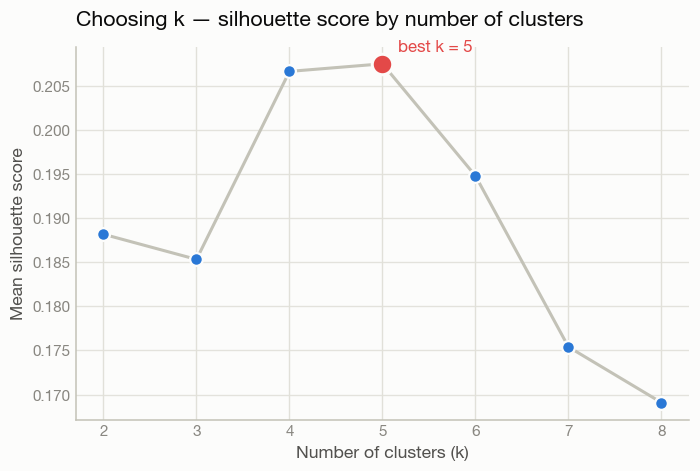

In [4]:
ks=list(range(2,9)); sils=[]
for k in ks:
    km=KMeans(n_clusters=k,n_init=10,random_state=42).fit(X)
    sils.append(silhouette_score(X,km.labels_))
best_k=ks[int(np.argmax(sils))]

fig,ax=plt.subplots(figsize=(7.2,4.4))
ax.plot(ks,sils,"-",color=AXIS,lw=2,zorder=1)
ax.scatter(ks,sils,s=70,color=BLUE,zorder=3,edgecolor=SURFACE,linewidth=1.5)
ax.scatter([best_k],[max(sils)],s=180,color=RED,zorder=4,edgecolor=SURFACE,linewidth=2)
ax.annotate(f"best k = {best_k}",(best_k,max(sils)),textcoords="offset points",
            xytext=(10,8),color=RED,fontweight="bold")
style_ax(ax,"Choosing k — silhouette score by number of clusters",
         "Number of clusters (k)","Mean silhouette score")
fig.savefig(f"{OUT}/A1_silhouette.png"); plt.show()

In [5]:
km=KMeans(n_clusters=best_k,n_init=10,random_state=42).fit(X)
clust["cluster"]=km.labels_
# relabel clusters in ascending order of suppression rate → stable, meaningful colours
order=clust.groupby("cluster")["suppression"].mean().sort_values().index.tolist()
remap={old:new for new,old in enumerate(order)}
clust["cluster"]=clust["cluster"].map(remap)
Xc=km.cluster_centers_[order]          # centroids in standardised space, reordered
print("cluster sizes:", clust["cluster"].value_counts().sort_index().to_dict())

cluster sizes: {0: 402, 1: 492, 2: 613, 3: 265, 4: 263}


### The phenotypes in 2-D (PCA)
Principal-component projection just for visualisation — each dot is a patient, coloured by cluster; the large **X** marks each cluster centroid.

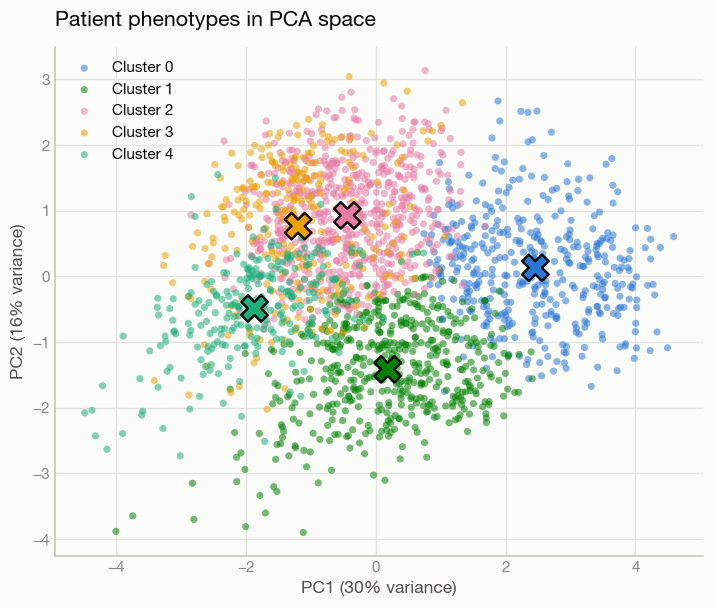

In [6]:
pca=PCA(n_components=2,random_state=42).fit(X); P=pca.transform(X); ev=pca.explained_variance_ratio_*100
fig,ax=plt.subplots(figsize=(7.6,6.0))
for c in range(best_k):
    m=clust["cluster"].values==c
    ax.scatter(P[m,0],P[m,1],s=22,color=CAT[c],alpha=0.55,edgecolor="none",label=f"Cluster {c}")
Pc=pca.transform(Xc)
ax.scatter(Pc[:,0],Pc[:,1],s=300,marker="X",c=[CAT[c] for c in range(best_k)],
           edgecolor=INK,linewidth=1.6,zorder=5)
style_ax(ax,"Patient phenotypes in PCA space",
         f"PC1 ({ev[0]:.0f}% variance)",f"PC2 ({ev[1]:.0f}% variance)",grid_axis="both")
ax.legend(frameon=False,loc="best",fontsize=10)
fig.savefig(f"{OUT}/A2_pca.png"); plt.show()

### What defines each phenotype?
The heatmap shows each cluster's **standardised** average for every feature (z-score):
**red = above** the cohort average, **blue = below**. Read each row as a clinical portrait.

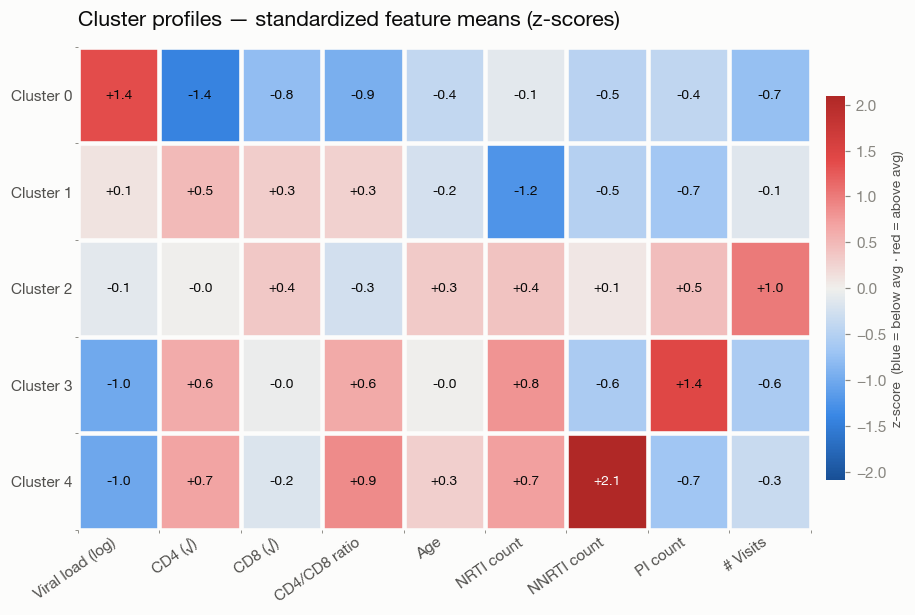

In [7]:
prof=pd.DataFrame(Xc,columns=FEATS); vmax=np.abs(Xc).max()
fig,ax=plt.subplots(figsize=(9.0,0.7*best_k+2.2))
im=ax.imshow(prof.values,cmap=DIV_CMAP,vmin=-vmax,vmax=vmax,aspect="auto")
ax.set_xticks(range(len(FEATS))); ax.set_xticklabels([LABELS[f] for f in FEATS],rotation=35,ha="right",color=INK2)
ax.set_yticks(range(best_k)); ax.set_yticklabels([f"Cluster {c}" for c in range(best_k)],color=INK2)
for i in range(best_k):
    for j in range(len(FEATS)):
        v=prof.values[i,j]
        ax.text(j,i,f"{v:+.1f}",ha="center",va="center",
                color=(INK if abs(v)<0.9*vmax else SURFACE),fontsize=9)
ax.set_title("Cluster profiles — standardized feature means (z-scores)",color=INK,loc="left",pad=14)
cb=fig.colorbar(im,ax=ax,fraction=0.025,pad=0.02)
cb.set_label("z-score  (blue = below avg · red = above avg)",color=INK2,fontsize=9); cb.outline.set_visible(False)
ax.grid(False)
ax.set_xticks(np.arange(-.5,len(FEATS),1),minor=True); ax.set_yticks(np.arange(-.5,best_k,1),minor=True)
ax.grid(which="minor",color=SURFACE,linewidth=3); ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)
fig.savefig(f"{OUT}/A3_profiles.png"); plt.show()

### Do the phenotypes differ in outcome?
Now we bring back the held-out target: the share of each cluster that is virally suppressed.

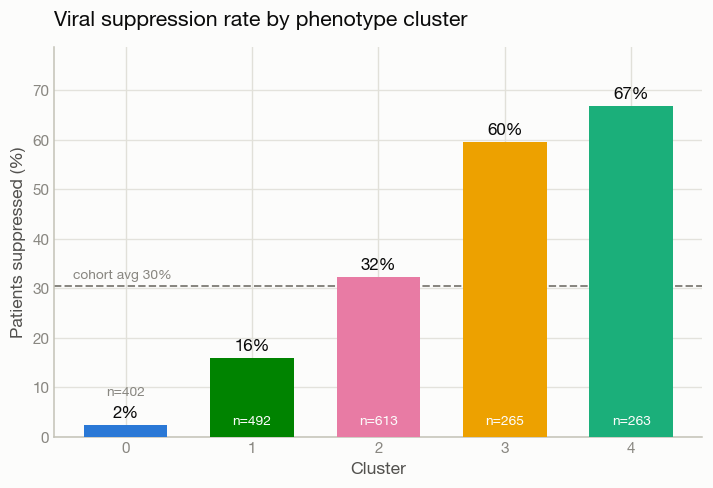

In [8]:
srate=clust.groupby("cluster")["suppression"].mean(); sizes=clust.groupby("cluster").size()
overall=clust["suppression"].mean()
fig,ax=plt.subplots(figsize=(7.6,4.6))
ax.bar(srate.index,srate.values*100,color=[CAT[c] for c in srate.index],width=0.66,zorder=3)
ax.axhline(overall*100,color=MUTED,ls="--",lw=1.3,zorder=2)
ax.annotate(f"cohort avg {overall*100:.0f}%",(-0.42,overall*100),textcoords="offset points",
            xytext=(0,5),color=MUTED,ha="left",fontsize=9)
ymax=max(srate.values*100)+12
for c in srate.index:
    h=srate[c]*100
    ax.text(c,h+1.5,f"{h:.0f}%",ha="center",color=INK,fontweight="bold")
    if h>12: ax.text(c,2.5,f"n={sizes[c]}",ha="center",color=SURFACE,fontsize=9,fontweight="bold")
    else:    ax.text(c,h+6.0,f"n={sizes[c]}",ha="center",color=MUTED,fontsize=9)
style_ax(ax,"Viral suppression rate by phenotype cluster","Cluster","Patients suppressed (%)")
ax.set_ylim(0,ymax); ax.set_xticks(list(srate.index))
fig.savefig(f"{OUT}/A4_suppression.png"); plt.show()

## Part B · Association-rule mining

Association rules find **co-occurring items** (like market-basket analysis). We treat each
**clinical visit** as a "basket" and turn its measurements into discrete *items*:

| Group | Items |
|---|---|
| CD4 count | `CD4:low(<200)` · `CD4:mid(200-500)` · `CD4:high(>500)` |
| Viral load | `VL:low(<1k)` · `VL:mid(1k-100k)` · `VL:high(>100k)` |
| Age | `Age:<35` · `Age:35-45` · `Age:45+` |
| Treatment | `NRTI/NNRTI/PI : yes\|none` |
| Behaviour | `Drug:yes\|no` |
| Genetics | `Hgb:AA\|AS\|SS` · `APOB:GG\|GT\|TT` |
| Outcome | `Suppressed` · `NotSuppressed` |

Each rule *antecedent → consequent* is scored by **support** (how often it occurs),
**confidence** (P(consequent | antecedent)), and **lift** (confidence ÷ base rate;
> 1 means positively associated). Apriori is implemented from scratch below (no `mlxtend`
dependency).

> ⚠️ **Tautology caveat.** `undetectable` (suppressed) is essentially a *threshold on viral
> load*, so `VL:* → Suppressed/NotSuppressed` rules are near-circular. In the final chart we
> **exclude viral-load items** from the antecedents so the surfaced patterns are genuinely
> informative (immune status, treatment, behaviour, genetics).


In [9]:
def band(v,edges,names):
    if pd.isna(v): return None
    for e,n in zip(edges,names):
        if v<=e: return n
    return names[-1]

def build_items(r):
    items=[]
    cd4=band(r["CD4N"],[200,500,1e9],["CD4:low(<200)","CD4:mid(200-500)","CD4:high(>500)"])
    if cd4: items.append(cd4)
    vl=band(r["vload"],[1000,100000,1e12],["VL:low(<1k)","VL:mid(1k-100k)","VL:high(>100k)"])
    if vl: items.append(vl)
    ag=band(r["ageatvis"],[35,45,200],["Age:<35","Age:35-45","Age:45+"])
    if ag: items.append(ag)
    for col,name in [("nrti","NRTI"),("nnrti","NNRTI"),("pi","PI")]:
        v=r[col]
        if not pd.isna(v): items.append(f"{name}:{'yes' if v>0 else 'none'}")
    if not pd.isna(r["anydrug"]): items.append(f"Drug:{'yes' if r['anydrug']==1 else 'no'}")
    if isinstance(r["HgbgenSS"],str) and r["HgbgenSS"] in ("AA","AS","SS"): items.append(f"Hgb:{r['HgbgenSS']}")
    if isinstance(r["APOBgr"],str): items.append(f"APOB:{r['APOBgr'].replace('/','')}")
    if not pd.isna(r["undetectable"]): items.append("Suppressed" if r["undetectable"]==1 else "NotSuppressed")
    return items

transactions=[set(build_items(r)) for _,r in df.iterrows()]
transactions=[t for t in transactions if len(t)>=2]
print(f"{len(transactions):,} usable visit-baskets")

45,504 usable visit-baskets


In [10]:
def apriori(transactions,min_support=0.05,max_len=3):
    N=len(transactions); minc=min_support*N
    c1=Counter()
    for t in transactions:
        for i in t: c1[frozenset([i])]+=1
    freq={k:v for k,v in c1.items() if v>=minc}; all_freq=dict(freq)
    k=2; current=list(freq.keys())
    while current and k<=max_len:
        cand=set()
        for i in range(len(current)):
            for j in range(i+1,len(current)):
                u=current[i]|current[j]
                if len(u)==k: cand.add(u)
        cand=[c for c in cand if all(frozenset(s) in all_freq for s in combinations(c,k-1))]
        counts=Counter()
        for t in transactions:
            for c in cand:
                if c<=t: counts[c]+=1
        freq={k2:v for k2,v in counts.items() if v>=minc}; all_freq.update(freq)
        current=list(freq.keys()); k+=1
    return {k:v/N for k,v in all_freq.items()}

def gen_rules(freq_sets,min_conf=0.6,min_lift=1.1):
    rules=[]
    for iset,sup in freq_sets.items():
        if len(iset)<2: continue
        for r in range(1,len(iset)):
            for ante in combinations(iset,r):
                ante=frozenset(ante); cons=iset-ante
                if ante not in freq_sets or cons not in freq_sets: continue
                conf=sup/freq_sets[ante]; lift=conf/freq_sets[cons]
                if conf>=min_conf and lift>=min_lift:
                    rules.append(dict(ante=ante,cons=cons,support=sup,confidence=conf,lift=lift))
    return pd.DataFrame(rules)

freq_sets=apriori(transactions,min_support=0.05,max_len=3)
rules=gen_rules(freq_sets,min_conf=0.6,min_lift=1.1)
def fmt(s): return " + ".join(sorted(s))
def rule_label(r): return f"{fmt(r['ante'])}  {ARROW}  {fmt(r['cons'])}"
rules["rule"]=rules.apply(lambda r: f"{fmt(r['ante'])}  ->  {fmt(r['cons'])}",axis=1)
rules=rules.sort_values("lift",ascending=False).reset_index(drop=True)
print(f"{len(freq_sets):,} frequent itemsets   ·   {len(rules):,} rules (support≥5%, conf≥60%, lift≥1.1)")
rules[["rule","support","confidence","lift"]].head(10).round(3)

558 frequent itemsets   ·   401 rules (support≥5%, conf≥60%, lift≥1.1)


,rule,support,confidence,lift
0,PI:none + Suppressed -> NNRTI:yes,0.079,0.663,3.791
1,NNRTI:yes -> NRTI:yes + PI:none,0.138,0.787,3.288
2,NNRTI:yes + VL:low(<1k) -> Suppressed,0.095,0.738,3.036
3,NNRTI:yes -> PI:none + VL:low(<1k),0.105,0.602,2.978
4,NNRTI:none + PI:none -> NRTI:none,0.220,0.684,2.963
5,NRTI:none -> NNRTI:none + PI:none,0.220,0.953,2.963
6,Drug:no + VL:low(<1k) -> Suppressed,0.138,0.696,2.864
7,CD4:high(>500) + NNRTI:yes -> Suppressed,0.060,0.693,2.849
8,PI:none + VL:mid(1k-100k) -> NRTI:none,0.132,0.657,2.845
9,PI:yes + VL:low(<1k) -> Suppressed,0.124,0.688,2.831


### Strongest rules overall
Horizontal bars ranked by lift; darker blue = higher confidence.

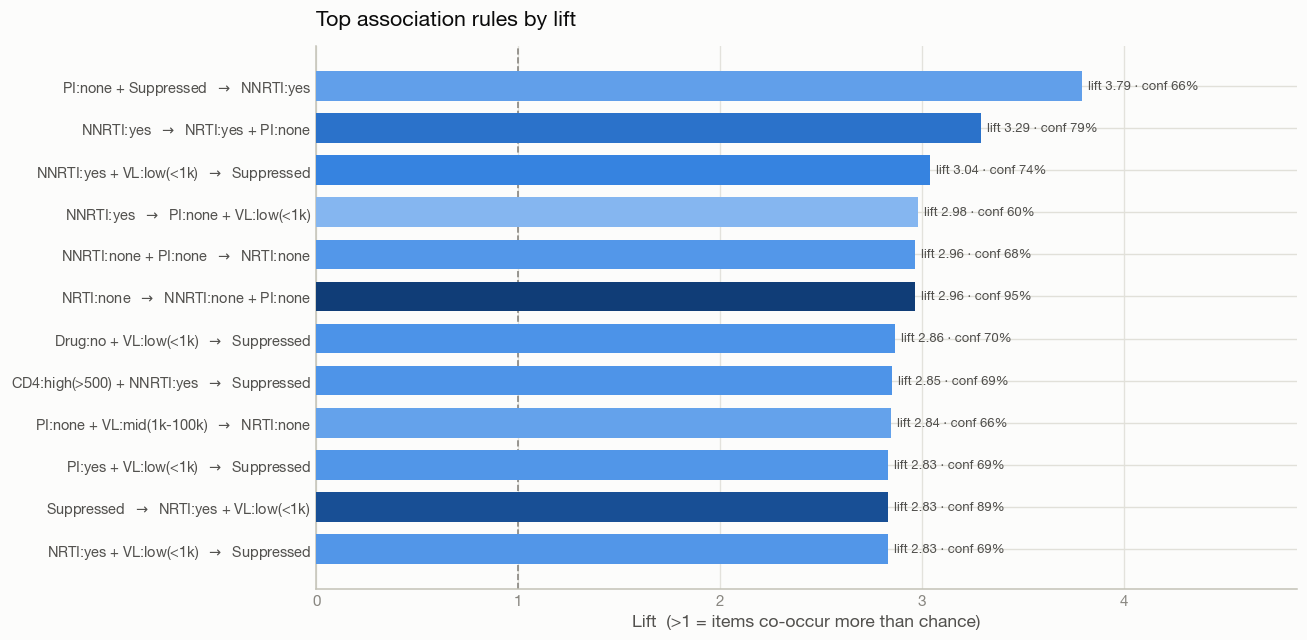

In [11]:
topn=rules.head(12).iloc[::-1]
fig,ax=plt.subplots(figsize=(11.5,6.4)); ypos=np.arange(len(topn))
norm=mpl.colors.Normalize(topn["confidence"].min(),topn["confidence"].max())
colors=[SEQ_CMAP(0.25+0.7*norm(c)) for c in topn["confidence"]]
ax.barh(ypos,topn["lift"],color=colors,zorder=3,height=0.7)
ax.set_yticks(ypos); ax.set_yticklabels([rule_label(r) for _,r in topn.iterrows()],fontsize=9.5,color=INK2)
for y,(l,c) in enumerate(zip(topn["lift"],topn["confidence"])):
    ax.text(l+0.03,y,f"lift {l:.2f} · conf {c*100:.0f}%",va="center",fontsize=8.5,color=INK2)
ax.axvline(1.0,color=MUTED,ls="--",lw=1.1)
style_ax(ax,"Top association rules by lift","Lift  (>1 = items co-occur more than chance)",None,grid_axis="x")
ax.set_xlim(0,topn["lift"].max()*1.28)
fig.savefig(f"{OUT}/B1_top_rules.png"); plt.show()

### The full rule landscape
Every rule plotted by support × confidence, coloured by lift. Top-right = frequent *and* reliable.

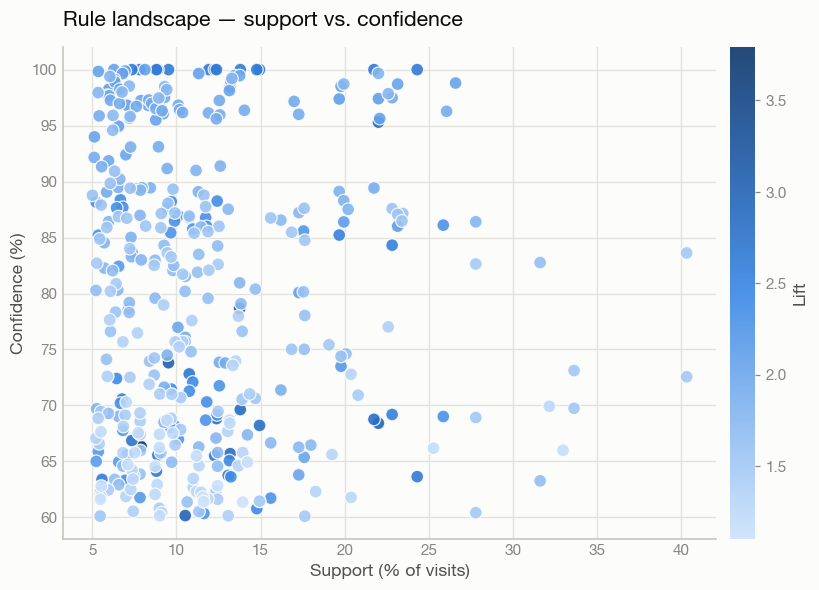

In [12]:
fig,ax=plt.subplots(figsize=(8.2,5.8))
sc=ax.scatter(rules["support"]*100,rules["confidence"]*100,c=rules["lift"],cmap=SEQ_CMAP,
              s=70,edgecolor=SURFACE,linewidth=0.8,alpha=0.9,zorder=3)
cb=fig.colorbar(sc,ax=ax,fraction=0.045,pad=0.02); cb.set_label("Lift",color=INK2); cb.outline.set_visible(False)
style_ax(ax,"Rule landscape — support vs. confidence","Support (% of visits)","Confidence (%)",grid_axis="both")
fig.savefig(f"{OUT}/B2_scatter.png"); plt.show()

### What predicts suppression? (viral-load items excluded)
A diverging view: patterns pushing **toward** suppression grow to the right (blue); patterns
pushing toward **non**-suppression grow to the left (red). Viral-load antecedents are removed
to avoid the tautology noted above.

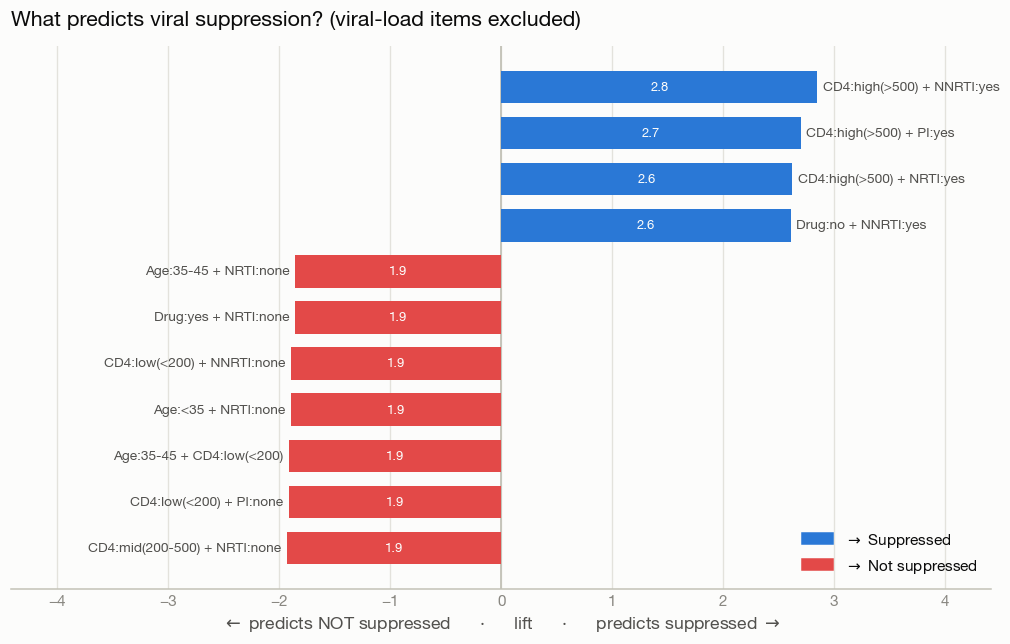

In [13]:
def no_vl(ante): return not any(str(i).startswith("VL:") for i in ante)
pred=rules[rules["cons"].apply(lambda s: s in ({"Suppressed"},{"NotSuppressed"})) & rules["ante"].apply(no_vl)].copy()
pred["outcome"]=pred["cons"].apply(lambda s: list(s)[0])
top_sup=pred[pred.outcome=="Suppressed"].sort_values("lift",ascending=False).head(7)
top_not=pred[pred.outcome=="NotSuppressed"].sort_values("lift",ascending=False).head(7)
plot=pd.concat([top_not,top_sup]).copy()
plot["signed"]=np.where(plot.outcome=="Suppressed",plot["lift"],-plot["lift"])
plot=plot.sort_values("signed").reset_index(drop=True)
fig,ax=plt.subplots(figsize=(11.5,6.4)); ypos=np.arange(len(plot))
cols=[BLUE if o=="Suppressed" else RED for o in plot.outcome]
ax.barh(ypos,plot["signed"],color=cols,zorder=3,height=0.7); ax.axvline(0,color=AXIS,lw=1.2)
for y,row in plot.iterrows():
    right=row.outcome=="Suppressed"
    ax.text(row.signed+(0.05 if right else -0.05),y,fmt(row.ante),va="center",
            ha="left" if right else "right",fontsize=9,color=INK2)
    ax.text(row.signed/2,y,f"{row.lift:.1f}",va="center",ha="center",fontsize=8.5,color=SURFACE,fontweight="bold")
leg=[Patch(color=BLUE,label=f"{ARROW} Suppressed"),Patch(color=RED,label=f"{ARROW} Not suppressed")]
ax.legend(handles=leg,frameon=False,loc="lower right",fontsize=10)
style_ax(ax,"What predicts viral suppression? (viral-load items excluded)",
         r"$\leftarrow$ predicts NOT suppressed      ·      lift      ·      predicts suppressed $\rightarrow$",
         None,grid_axis="x")
ax.set_yticks([]); xmax=plot["lift"].max()*1.55; ax.set_xlim(-xmax,xmax)
ax.spines["left"].set_visible(False)
fig.savefig(f"{OUT}/B3_suppression_rules.png"); plt.show()

## Takeaways

**Clustering** separates the cohort into distinct phenotypes whose suppression rates span a
wide range (see the last bar chart) — the low-CD4 / high-viral-load / untreated group sits
far below the cohort average, while the well-treated, high-CD4 groups sit well above. This is
a *clinically interpretable* stratification learned **without** using the label, and it
tracks the outcome strongly — a useful sanity check on the supervised models and a candidate
feature (cluster id) for them.

**Association rules** recover coherent clinical structure: on-treatment + high-CD4 patterns
associate with suppression; untreated / low-CD4 / recreational-drug patterns associate with
non-suppression. The viral-load ↔ suppression rules are strong but near-tautological and were
deliberately excluded from the final chart.

**Caveats.** (1) A "basket" is a *visit*, not a patient, so support counts are inflated by
patients with many visits. (2) Genotype items are missing for >50% of visits, shrinking the
support base for genetic rules. (3) Cluster assignment used per-patient means and only
patients with complete marker profiles.
